# KNN: entenderlo visualmente

KNN significa **K-Nearest Neighbors**: los `k` vecinos más cercanos.

La idea es muy simple:

> Para predecir un punto nuevo, KNN busca los puntos más cercanos que ya conoce y usa sus respuestas.

Si estamos clasificando, votan los vecinos.  
Si estamos haciendo regresión, promediamos los valores de los vecinos.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')


## 1. La distancia entre dos puntos

En 2D, cada observación tiene dos coordenadas.

Por ejemplo:

- eje x: ingreso
- eje y: ahorro

Para saber qué puntos son cercanos, usamos una distancia. La más común es la distancia euclidiana.


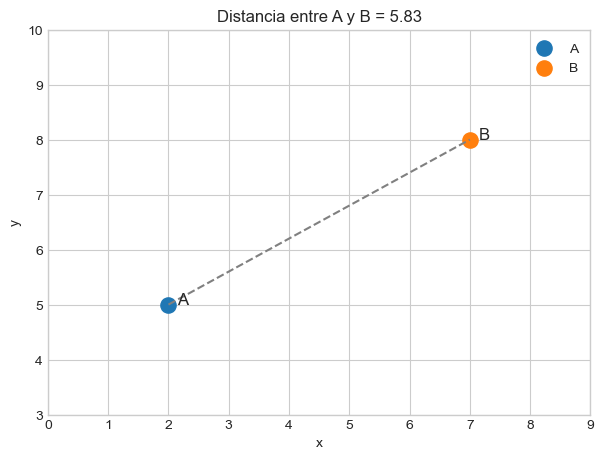

In [2]:
A = np.array([2, 5])
B = np.array([7, 8])

distancia = np.sqrt((A[0] - B[0])**2 + (A[1] - B[1])**2)

plt.figure(figsize=(7, 5))
plt.scatter(A[0], A[1], s=120, label='A')
plt.scatter(B[0], B[1], s=120, label='B')
plt.plot([A[0], B[0]], [A[1], B[1]], linestyle='--', color='gray')
plt.text(A[0] + 0.15, A[1], 'A', fontsize=12)
plt.text(B[0] + 0.15, B[1], 'B', fontsize=12)
plt.title(f'Distancia entre A y B = {distancia:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, 9)
plt.ylim(3, 10)
plt.legend()
plt.show()


## 2. Clasificación con KNN en 2D

Vamos a inventar dos grupos:

- clientes tipo `A`,
- clientes tipo `B`.

Cada punto tiene dos variables. Queremos clasificar un cliente nuevo mirando sus vecinos.


In [3]:
grupo_a = np.random.normal(loc=[3, 6], scale=[0.9, 0.9], size=(18, 2))
grupo_b = np.random.normal(loc=[7, 3], scale=[1.0, 0.9], size=(18, 2))

X = np.vstack([grupo_a, grupo_b])
y = np.array(['A'] * len(grupo_a) + ['B'] * len(grupo_b))

punto_nuevo = np.array([5.1, 4.5])

datos = pd.DataFrame(X, columns=['ingreso', 'ahorro'])
datos['grupo'] = y
datos.head()


,ingreso,ahorro,grupo
0,3.447043,5.875562,A
1,3.582920,7.370727,A
2,2.789262,5.789277,A
3,4.421292,6.690691,A
4,2.577473,6.488304,A


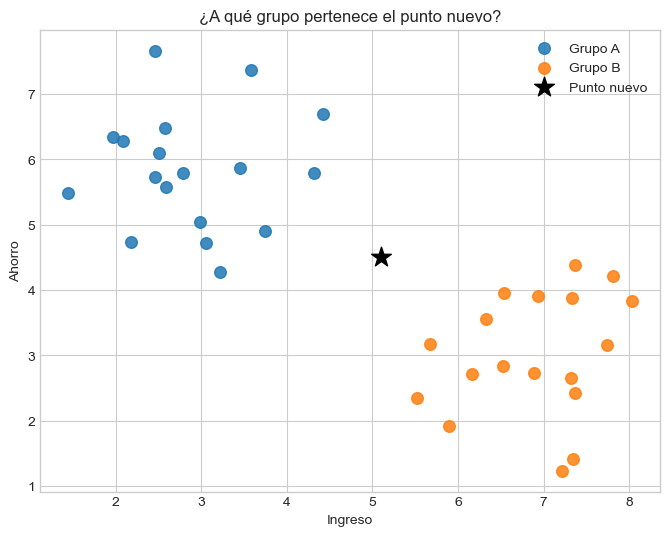

In [4]:
plt.figure(figsize=(8, 6))

for grupo, color in [('A', 'tab:blue'), ('B', 'tab:orange')]:
    subset = datos[datos['grupo'] == grupo]
    plt.scatter(subset['ingreso'], subset['ahorro'], s=70, color=color, label=f'Grupo {grupo}', alpha=0.85)

plt.scatter(punto_nuevo[0], punto_nuevo[1], s=220, marker='*', color='black', label='Punto nuevo')
plt.xlabel('Ingreso')
plt.ylabel('Ahorro')
plt.title('¿A qué grupo pertenece el punto nuevo?')
plt.legend()
plt.show()


## 3. Los vecinos más cercanos

KNN calcula la distancia del punto nuevo a todos los puntos conocidos.

Después ordena esas distancias y se queda con los `k` más cercanos.


In [5]:
distancias = np.sqrt(np.sum((X - punto_nuevo) ** 2, axis=1))

tabla_distancias = pd.DataFrame({
    'ingreso': X[:, 0],
    'ahorro': X[:, 1],
    'grupo': y,
    'distancia_al_punto_nuevo': distancias,
}).sort_values('distancia_al_punto_nuevo')

tabla_distancias.head(10).round(3)


,ingreso,ahorro,grupo,distancia_al_punto_nuevo
17,3.740,4.901,A,1.418
19,5.672,3.177,B,1.441
10,4.319,5.797,A,1.514
23,6.539,3.951,B,1.540
26,6.323,3.551,B,1.548
6,3.218,4.278,A,1.895
33,6.928,3.903,B,1.923
11,3.061,4.718,A,2.051
28,6.161,2.722,B,2.071
0,3.447,5.876,A,2.150


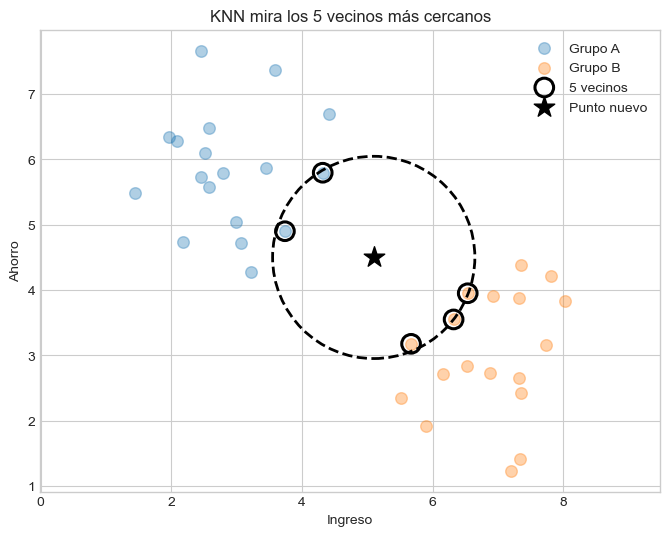

In [6]:
k = 5
vecinos = tabla_distancias.head(k)
radio = vecinos['distancia_al_punto_nuevo'].max()

plt.figure(figsize=(8, 6))

for grupo, color in [('A', 'tab:blue'), ('B', 'tab:orange')]:
    subset = datos[datos['grupo'] == grupo]
    plt.scatter(subset['ingreso'], subset['ahorro'], s=70, color=color, label=f'Grupo {grupo}', alpha=0.35)

plt.scatter(vecinos['ingreso'], vecinos['ahorro'], s=180, facecolors='none', edgecolors='black', linewidth=2.2, label=f'{k} vecinos')
plt.scatter(punto_nuevo[0], punto_nuevo[1], s=240, marker='*', color='black', label='Punto nuevo')

circulo = plt.Circle(punto_nuevo, radio, color='black', fill=False, linestyle='--', linewidth=2)
plt.gca().add_patch(circulo)

plt.xlabel('Ingreso')
plt.ylabel('Ahorro')
plt.title(f'KNN mira los {k} vecinos más cercanos')
plt.legend()
plt.axis('equal')
plt.show()


In [7]:
votos = vecinos['grupo'].value_counts()
prediccion = votos.idxmax()

print('Votos de los vecinos:')
print(votos)
print('\nPredicción para el punto nuevo:', prediccion)


Votos de los vecinos:
grupo
B    3
A    2
Name: count, dtype: int64

Predicción para el punto nuevo: B


## 4. ¿Qué pasa si cambio `k`?

`k` controla cuántos vecinos votan.

- `k` pequeño: el modelo es muy sensible a puntos individuales.
- `k` grande: el modelo se vuelve más estable, pero puede ignorar detalles locales.


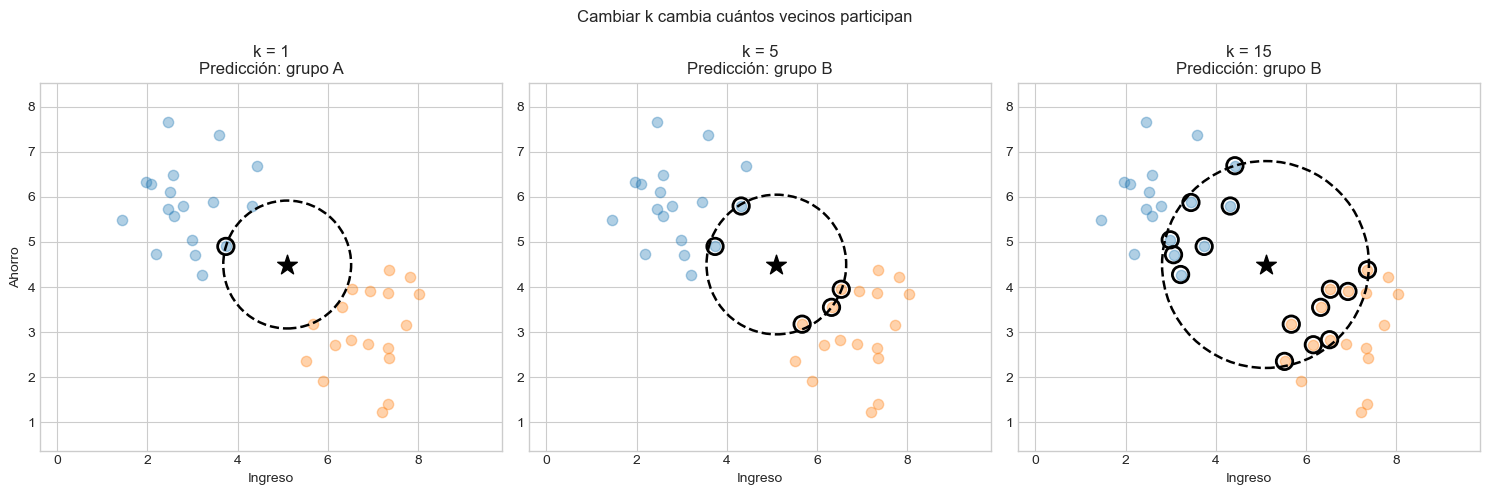

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, k in zip(axes, [1, 5, 15]):
    vecinos_k = tabla_distancias.head(k)
    radio_k = vecinos_k['distancia_al_punto_nuevo'].max()
    pred_k = vecinos_k['grupo'].value_counts().idxmax()

    for grupo, color in [('A', 'tab:blue'), ('B', 'tab:orange')]:
        subset = datos[datos['grupo'] == grupo]
        ax.scatter(subset['ingreso'], subset['ahorro'], s=55, color=color, alpha=0.35)

    ax.scatter(vecinos_k['ingreso'], vecinos_k['ahorro'], s=140, facecolors='none', edgecolors='black', linewidth=2)
    ax.scatter(punto_nuevo[0], punto_nuevo[1], s=220, marker='*', color='black')
    ax.add_patch(plt.Circle(punto_nuevo, radio_k, color='black', fill=False, linestyle='--', linewidth=1.8))
    ax.set_title(f'k = {k}\nPredicción: grupo {pred_k}')
    ax.set_xlabel('Ingreso')
    ax.axis('equal')

axes[0].set_ylabel('Ahorro')
plt.suptitle('Cambiar k cambia cuántos vecinos participan')
plt.tight_layout()
plt.show()


## 5. Mapa de decisión

Otra forma visual de entender KNN es colorear el plano.

Cada región muestra qué grupo predice el modelo para un punto que caiga ahí.


In [9]:
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X, y)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250)
)

grid = np.c_[xx.ravel(), yy.ravel()]
pred_grid = modelo_knn.predict(grid)
pred_num = (pred_grid == 'B').astype(int).reshape(xx.shape)


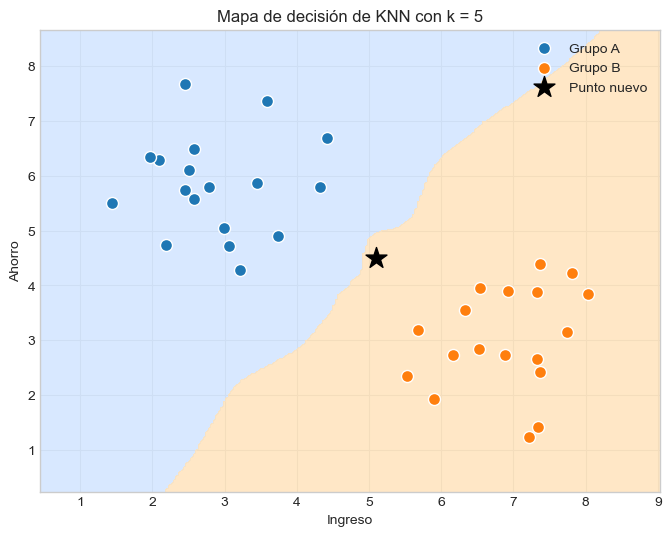

In [10]:
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, pred_num, levels=[-0.5, 0.5, 1.5], colors=['#cfe3ff', '#ffe2b8'], alpha=0.8)

for grupo, color in [('A', 'tab:blue'), ('B', 'tab:orange')]:
    subset = datos[datos['grupo'] == grupo]
    plt.scatter(subset['ingreso'], subset['ahorro'], s=75, color=color, edgecolor='white', label=f'Grupo {grupo}')

plt.scatter(punto_nuevo[0], punto_nuevo[1], s=250, marker='*', color='black', label='Punto nuevo')
plt.xlabel('Ingreso')
plt.ylabel('Ahorro')
plt.title('Mapa de decisión de KNN con k = 5')
plt.legend()
plt.show()


## 6. KNN también sirve para regresión

En regresión no hay votos.

Si queremos predecir un número, KNN toma el promedio de los valores de los vecinos.


In [11]:
np.random.seed(4)

X_reg = np.linspace(0, 10, 35).reshape(-1, 1)
y_reg = 30 + 5 * X_reg.ravel() + 12 * np.sin(X_reg.ravel()) + np.random.normal(0, 4, len(X_reg))

punto_reg = np.array([[6.2]])
k_reg = 5

modelo_reg = KNeighborsRegressor(n_neighbors=k_reg)
modelo_reg.fit(X_reg, y_reg)
pred_reg = modelo_reg.predict(punto_reg)[0]

dist_reg = np.abs(X_reg.ravel() - punto_reg[0, 0])
idx_vecinos_reg = np.argsort(dist_reg)[:k_reg]


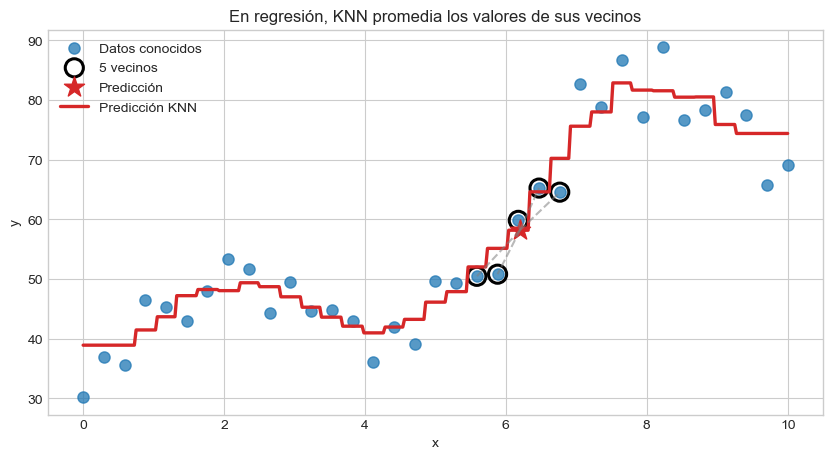

In [12]:
x_grid_reg = np.linspace(0, 10, 400).reshape(-1, 1)

plt.figure(figsize=(10, 5))
plt.scatter(X_reg, y_reg, s=65, color='tab:blue', alpha=0.75, label='Datos conocidos')
plt.scatter(X_reg[idx_vecinos_reg], y_reg[idx_vecinos_reg], s=170, facecolors='none', edgecolors='black', linewidth=2.2, label=f'{k_reg} vecinos')
plt.scatter(punto_reg[0, 0], pred_reg, s=230, marker='*', color='tab:red', label='Predicción')
plt.plot(x_grid_reg, modelo_reg.predict(x_grid_reg), color='tab:red', linewidth=2.4, label='Predicción KNN')

for idx in idx_vecinos_reg:
    plt.plot([punto_reg[0, 0], X_reg[idx, 0]], [pred_reg, y_reg[idx]], color='gray', linestyle='--', alpha=0.55)

plt.xlabel('x')
plt.ylabel('y')
plt.title('En regresión, KNN promedia los valores de sus vecinos')
plt.legend()
plt.show()


In [13]:
pd.DataFrame({
    'x_vecino': X_reg[idx_vecinos_reg].ravel(),
    'y_vecino': y_reg[idx_vecinos_reg],
}).assign(promedio_usado=pred_reg).round(2)


,x_vecino,y_vecino,promedio_usado
0,6.18,59.82,58.17
1,6.47,65.23,58.17
2,5.88,50.80,58.17
3,6.76,64.55,58.17
4,5.59,50.44,58.17


## 7. Aplicación con housing.csv

Ahora usamos el dataset de casas.

Como KNN depende de distancias, `StandardScaler` es importante: una variable con números grandes puede dominar la distancia.


In [15]:
df = pd.read_csv('../data/housing.csv')
df = pd.get_dummies(df)
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)


In [ ]:
valores_k = np.arange(1, 51)
r2_results = []
rmse_results = []

for k in valores_k:
    modelo = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor(n_neighbors=k))
    ])
    modelo.fit(X_train, y_train)
    predicciones = modelo.predict(X_test)

    r2_results.append(r2_score(y_test, predicciones))
    rmse_results.append(np.sqrt(mean_squared_error(y_test, predicciones)))

resultados_k = pd.DataFrame({
    'k': valores_k,
    'R2 prueba': r2_results,
    'RMSE prueba': rmse_results,
})

resultados_k.sort_values('R2 prueba', ascending=False).head(10).round(3)


,k,R2 prueba,RMSE prueba
13,14,0.723,60320.901
14,15,0.722,60402.522
11,12,0.721,60518.803
12,13,0.721,60541.037
10,11,0.721,60551.418
15,16,0.720,60603.274
9,10,0.720,60629.569
16,17,0.719,60722.061
8,9,0.718,60790.280
17,18,0.718,60791.168


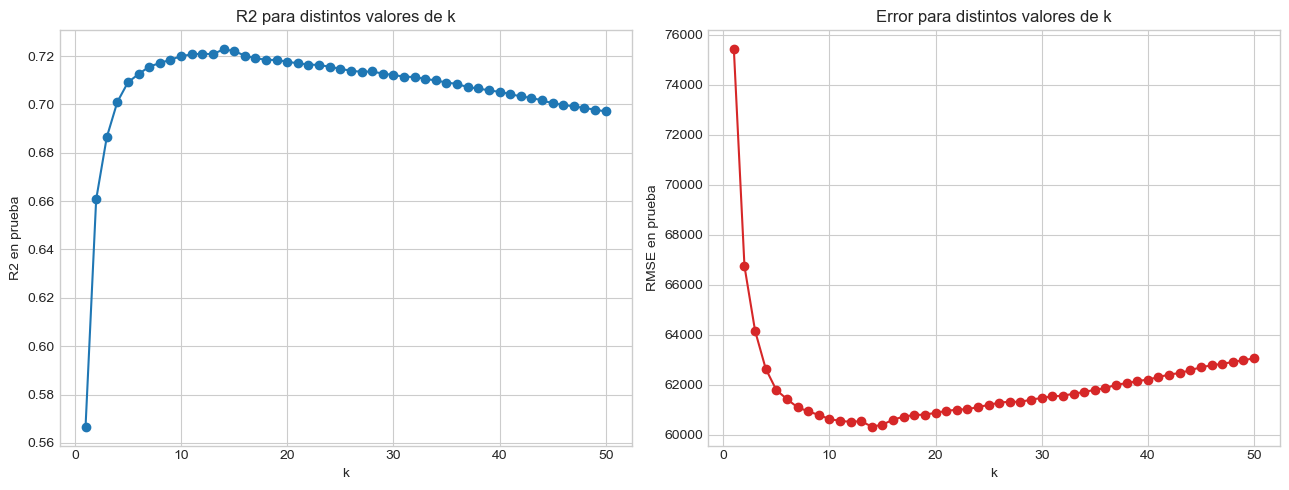

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(resultados_k['k'], resultados_k['R2 prueba'], marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('R2 en prueba')
axes[0].set_title('R2 para distintos valores de k')

axes[1].plot(resultados_k['k'], resultados_k['RMSE prueba'], marker='o', color='tab:red')
axes[1].set_xlabel('k')
axes[1].set_ylabel('RMSE en prueba')
axes[1].set_title('Error para distintos valores de k')

plt.tight_layout()
plt.show()


## Cierre

KNN es fácil de explicar si lo pensamos así:

1. Guardamos ejemplos conocidos.
2. Llega un punto nuevo.
3. Medimos distancias.
4. Elegimos los `k` vecinos más cercanos.
5. Para clasificación, votan.
6. Para regresión, se promedian.

La parte delicada es escoger `k` y cuidar la escala de las variables.
